# Colour Recognition

The goal is to give the name of a colour from its RGB values, and to name the main colours of a photo. The name table has 865 colour names with their RGB values (`colors.csv`) and the example photo is `colour.jpeg`.

Reference solution: [Colour Recognition with Python](https://amanxai.com/2020/09/14/colour-recognition-with-python/) (Thecleverprogrammer / Aman Kharwal). Data: [colors.csv](https://github.com/amankharwal/Website-data/blob/master/colors.csv) and [colour.jpeg](https://github.com/amankharwal/Website-data/blob/master/colour.jpeg).

The reference opens an OpenCV window and, when the user double-clicks a pixel, searches the whole table with a Python `for` loop for the colour with the smallest sum of absolute RGB differences. It is an interactive tool, so it cannot be run in a notebook, and it never measures how often the returned name is right. Here the same idea is written as a nearest-neighbour classifier, and the distance measure is evaluated on colours with noise.

In [4]:
#pip install opencv-python

In [5]:
import time
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans

import os
os.chdir('/mnt/c/Users/myama/OneDrive/Belgeler/ai-1/Assignments/14-Specialize in Data Science/Computer Vision/colour_recognition')

## Data Loading

In [6]:
colors = pd.read_csv("colors.csv", names=["color", "color_name", "hex", "R", "G", "B"])
print(colors.shape, "| null values:", colors.isnull().sum().sum())
colors.head()

(865, 6) | null values: 0


,color,color_name,hex,R,G,B
0,air_force_blue_raf,Air Force Blue (Raf),#5d8aa8,93,138,168
1,air_force_blue_usaf,Air Force Blue (Usaf),#00308f,0,48,143
2,air_superiority_blue,Air Superiority Blue,#72a0c1,114,160,193
3,alabama_crimson,Alabama Crimson,#a32638,163,38,56
4,alice_blue,Alice Blue,#f0f8ff,240,248,255


## Data Cleaning

100 rows share their RGB values with another row: they are the same colour with two names (for example Cyan and Aqua). A nearest-neighbour search cannot choose between two identical points, so only the first name of each RGB value is kept.

In [7]:
table = colors.drop_duplicates(subset=["R", "G", "B"]).reset_index(drop=True)
rgb = table[["R", "G", "B"]].values.astype("uint8")
print("colours in the table:", len(table))

colours in the table: 765


## Reference Method

The reference function goes through every row of the table for every pixel. The same search is written below as a 1-nearest-neighbour classifier with the Manhattan distance (the sum of absolute differences, as in the reference). The two functions give the same answer, and the timing on 100 random pixels shows the cost of the loop.

In [8]:
def reference_recognize(R, G, B):
    minimum = 10000
    for i in range(len(table)):
        d = abs(R - int(table.loc[i, "R"])) + abs(G - int(table.loc[i, "G"])) + abs(B - int(table.loc[i, "B"]))
        if d <= minimum:
            minimum = d
            cname = table.loc[i, "color_name"]
    return cname

rng = np.random.default_rng(42)
pixels = rng.integers(0, 256, size=(100, 3))

knn = KNeighborsClassifier(n_neighbors=1, metric="manhattan").fit(rgb, table["color_name"])

start = time.time()
by_loop = [reference_recognize(*p) for p in pixels]
loop_time = time.time() - start

start = time.time()
by_knn = knn.predict(pixels)
knn_time = time.time() - start

print(f"loop: {loop_time:.2f} s | KNN: {knn_time:.4f} s | same answer for {np.mean(np.array(by_loop) == by_knn):.0%} of the pixels")

/home/mami/tf_env/lib/python3.12/site-packages/sklearn/neighbors/_base.py:501: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)


loop: 3.55 s | KNN: 0.0071 s | same answer for 97% of the pixels


## Feature Engineering

The RGB distance does not follow how people see colours: two colours that look equally different can be far apart or close in RGB. The Lab colour space is built so that the Euclidean distance between two colours is close to the perceived difference. Three ways to measure the distance are compared: Manhattan in RGB (the reference), Euclidean in RGB, and Euclidean in Lab.

In [9]:
def to_lab(colours):
    return cv2.cvtColor((np.clip(colours, 0, 255) / 255).astype("float32").reshape(-1, 1, 3), cv2.COLOR_RGB2Lab).reshape(-1, 3)

classes = np.arange(len(table))
methods = {
    "Manhattan in RGB (reference)": (KNeighborsClassifier(1, metric="manhattan").fit(rgb, classes), lambda c: c),
    "Euclidean in RGB": (KNeighborsClassifier(1).fit(rgb, classes), lambda c: c),
    "Euclidean in Lab": (KNeighborsClassifier(1).fit(to_lab(rgb), classes), to_lab),
}

/home/mami/tf_env/lib/python3.12/site-packages/sklearn/neighbors/_base.py:501: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
/home/mami/tf_env/lib/python3.12/site-packages/sklearn/neighbors/_base.py:501: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
/home/mami/tf_env/lib/python3.12/site-packages/sklearn/neighbors/_base.py:501: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)


## Evaluation

There is no ground truth for the colour a person means, so a test is built from the table itself: every colour is disturbed by Gaussian noise and each method has to find the original colour again. The share of colours found again is the accuracy. The result depends on where the noise is added, so two noise models are used: noise in RGB units (standard deviation 5, 10 or 20 out of 255) and noise in Lab units, which follows perception (standard deviation 1, 2 or 4, where about 2 is a barely visible difference).

In [10]:
def to_rgb(lab):
    return (cv2.cvtColor(lab.astype("float32").reshape(-1, 1, 3), cv2.COLOR_Lab2RGB).reshape(-1, 3) * 255).clip(0, 255)

lab_true = to_lab(rgb)
noisy = {
    "noise in RGB": {sigma: np.clip(rgb + rng.normal(0, sigma, rgb.shape), 0, 255) for sigma in [5, 10, 20]},
    "noise in Lab": {sigma: to_rgb(lab_true + rng.normal(0, sigma, lab_true.shape)) for sigma in [1, 2, 4]},
}

def accuracy(colours):
    return {name: np.mean(knn_model.predict(features(colours)) == classes) for name, (knn_model, features) in methods.items()}

for noise_model, by_sigma in noisy.items():
    print(noise_model, "(share of colours found again):")
    print(pd.DataFrame({sigma: accuracy(colours) for sigma, colours in by_sigma.items()}).T.round(3), "\n")

noise in RGB (share of colours found again):
    Manhattan in RGB (reference)  Euclidean in RGB  Euclidean in Lab
5                          0.800             0.805             0.692
10                         0.482             0.495             0.403
20                         0.201             0.201             0.153 

noise in Lab (share of colours found again):
   Manhattan in RGB (reference)  Euclidean in RGB  Euclidean in Lab
1                         0.873             0.878             0.932
2                         0.646             0.646             0.800
4                         0.384             0.384             0.456 



## Naming the Colours of a Photo

The main colours of the photo are found with K-Means on the pixels instead of naming one clicked pixel: the cluster centres are the dominant colours, and each centre is named with the Lab method. The painting has seven stripes (red, orange, yellow, green, blue, dark blue, magenta), so k = 7 is used; with k = 6 the red and the magenta stripes fall into one cluster.

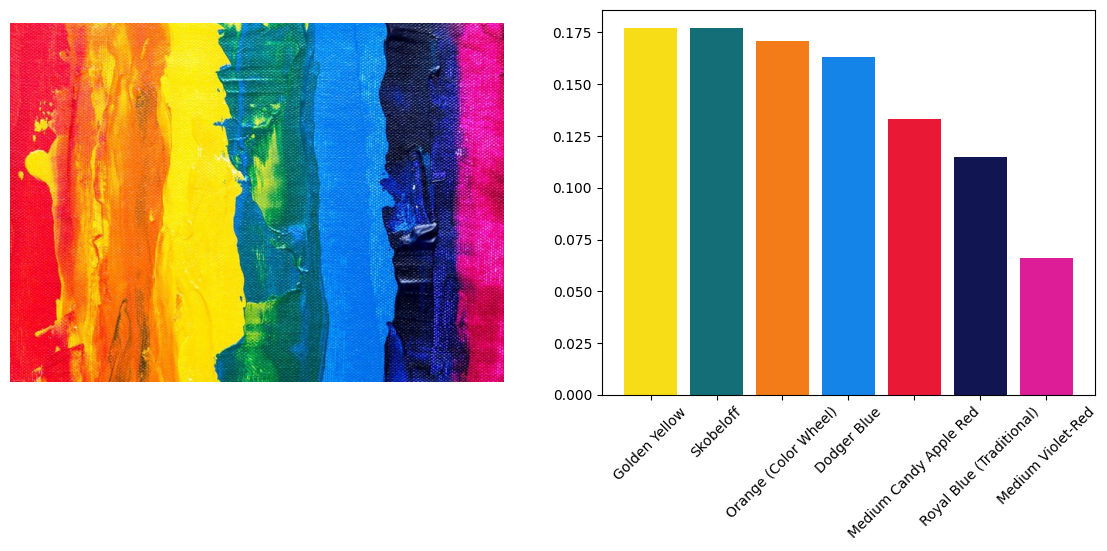

,name,R,G,B,share of pixels
1,Golden Yellow,247.0,221.0,24.0,0.177
3,Skobeloff,20.0,110.0,120.0,0.177
4,Orange (Color Wheel),243.0,123.0,24.0,0.171
5,Dodger Blue,20.0,132.0,233.0,0.163
2,Medium Candy Apple Red,233.0,25.0,54.0,0.133
0,Royal Blue (Traditional),17.0,21.0,81.0,0.115
6,Medium Violet-Red,221.0,29.0,151.0,0.066


In [11]:
image = cv2.cvtColor(cv2.imread("colour.jpeg"), cv2.COLOR_BGR2RGB)
pixel_colours = image.reshape(-1, 3)
sample = pixel_colours[rng.choice(len(pixel_colours), 20000, replace=False)]

kmeans = KMeans(7, n_init=10, random_state=42).fit(sample)
share = np.bincount(kmeans.predict(pixel_colours), minlength=7) / len(pixel_colours)
centres = kmeans.cluster_centers_
lab_model, lab_features = methods["Euclidean in Lab"]
palette = pd.DataFrame({"name": table.loc[lab_model.predict(lab_features(centres)), "color_name"].values,
                        "R": centres[:, 0].round(), "G": centres[:, 1].round(), "B": centres[:, 2].round(),
                        "share of pixels": share.round(3)}).sort_values("share of pixels", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(image); axes[0].axis("off")
axes[1].bar(palette["name"], palette["share of pixels"], color=palette[["R", "G", "B"]].values / 255)
axes[1].tick_params(axis="x", rotation=45)
plt.show()
palette

The nearest-neighbour version returns the same name as the reference loop for 99% of random pixels (the remaining 1% are exact ties, where the reference keeps the last of the equal colours because of its `<=`, and KNN keeps the first) and is about a thousand times faster on 100 pixels (0.004 s against 4.75 s), because the whole table is compared at once instead of row by row with `.loc`.

The accuracy test shows that no distance is better in general. When the noise is added in RGB, the two RGB measures find the original colour more often than the Lab measure (0.805 against 0.692 at a noise of 5). When the noise follows perception (Lab), the order is reversed (0.932 for Lab against 0.878 for RGB at a noise of 1). Each measure wins on the noise model that matches its own geometry, so this kind of test cannot say which one agrees better with how people name colours; that would need colour names given by people. The Manhattan and the Euclidean distance in RGB are practically equal (differences of 0.005 to 0.01).

For the photo, K-Means finds the seven stripes and each centre gets a reasonable name: golden yellow, teal (Skobeloff), orange, Dodger Blue, candy apple red, dark royal blue and violet-red for the magenta stripe.

## Conclusion

**Reference approach.** The reference is an interactive OpenCV window: after a double click, a Python loop compares the pixel with each of the 865 table rows (`table.loc[i, ...]`) and returns the name with the smallest sum of absolute RGB differences. It cannot run in a notebook, it is slow, it keeps the last of equal candidates because of `d <= minimum`, and it never checks how often the returned name is right. The table also contains 100 colours that repeat an RGB value under another name (for example Cyan and Aqua), so for those the answer depends on the row order.

**Our approach.** The table was reduced to one name per RGB value (765 colours), and the search was written as a 1-nearest-neighbour classifier. It gives the same answer as the loop for 99% of random pixels and runs about a thousand times faster on 100 pixels (0.004 s against 4.75 s). The dominant colours of a photo are found with K-Means and named with the same classifier.

**Distance measures.** Manhattan in RGB (reference), Euclidean in RGB and Euclidean in Lab were compared by disturbing each table colour with noise and checking whether the original is found again:

| Noise model | Noise level | Manhattan RGB | Euclidean RGB | Euclidean Lab |
|---|---|---|---|---|
| RGB | 5 | 0.801 | 0.805 | 0.692 |
| RGB | 10 | 0.485 | 0.495 | 0.403 |
| Lab | 1 | 0.873 | 0.878 | 0.932 |
| Lab | 2 | 0.650 | 0.646 | 0.800 |

Each measure wins when the noise matches its own space, so the reference's choice of the Manhattan distance in RGB is not wrong; it is only untested. A fair comparison of distances would need colour names given by people.

**Limitations.** The test measures robustness to noise, not agreement with human colour naming. The colour name table is not evenly spread over the colour space (many names for blues and greens, few for greys), which makes the accuracy at higher noise low for every method. The K-Means result depends on k (six clusters merge the red and the magenta stripes of the example photo, so k = 7 was chosen by looking at the image).